# DenseNet with on training set with removed background

Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torchvision.models import densenet121
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
from tqdm.auto import tqdm
import os


Device selection

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA GPU")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple MPS GPU")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using Apple MPS GPU


In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#DATA_PATH = "/content/drive/MyDrive/aml-2025-feathers-in-focus"
DATA_PATH = "../data"

TRAIN_CSV = os.path.join(DATA_PATH, "train_csv_rembg.csv")
TRAIN_PATH = os.path.join(DATA_PATH, "train_images_rembg")
TEST_PATH  = os.path.join(DATA_PATH, "test_images_rembg")

print("training set:", TRAIN_PATH)
print("csv found", os.path.exists(TRAIN_CSV))
print("training set not empty", len(os.listdir(TRAIN_PATH)) > 0)

training set: ../data/train_images_rembg
csv found True
training set not empty True


In [4]:
CHECKPOINT_DIR = "/content/drive/MyDrive/aml-2025-feathers-in-focus/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

BEST_CKPT_PATH = os.path.join(CHECKPOINT_DIR, "best_densenet.pt")
LAST_CKPT_PATH = os.path.join(CHECKPOINT_DIR, "last_densenet.pt")

OSError: [Errno 30] Read-only file system: '/content'

In [4]:
class ImageDFDataset(Dataset):
    def __init__(self, df, label_to_idx, transform=None):
        self.df = df.reset_index(drop=True)
        self.label_to_idx = label_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        rel_path = self.df.loc[idx, "image_path"]
        img_path = rel_path if os.path.isabs(rel_path) else os.path.join(DATA_PATH, rel_path)

        label_str = self.df.loc[idx, "label"]
        label = self.label_to_idx[label_str]

        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

def build_label_mapping(df_train):
    classes = sorted(df_train["label"].unique())
    label_to_idx = {c: i for i, c in enumerate(classes)}
    idx_to_label = {i: c for c, i in label_to_idx.items()}
    return label_to_idx, idx_to_label

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(128, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.1),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.5),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize(144),
    transforms.CenterCrop(128),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

def make_dataloaders(df_train, df_val, batch_size=64):

    label_to_idx, idx_to_label = build_label_mapping(df_train)
    num_classes = len(label_to_idx)

    train_dataset = ImageDFDataset(df_train, label_to_idx, transform=train_transform)
    val_dataset   = ImageDFDataset(df_val, label_to_idx, transform=val_transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory = True, persistent_workers = True)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory = True, persistent_workers = True)

    return train_loader, val_loader, num_classes, label_to_idx, idx_to_label

def build_densenet121(num_classes):
    model = models.densenet121(weights=None)  # NOT pretrained

    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(model.classifier.in_features, num_classes)
    )

    return model

def train_model(model, train_loader, val_loader, epochs=100, lr=1e-3,
                start_epoch=0, best_loss=float("inf")):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)
    print(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_loss = float("inf")

    epoch_bar = tqdm(range(start_epoch, epochs), desc="Epochs")

    for epoch in epoch_bar:
        model.train()
        running_loss = 0.0

        train_bar = tqdm(
            train_loader,
            desc=f"Train {epoch+1}/{epochs}",
            leave=False
        )

        for imgs, labels in train_bar:
            optimizer.zero_grad()

            imgs, labels_a, labels_b, lam = mixup(imgs, labels)
            imgs = imgs.to(device)
            labels_a = labels_a.to(device)
            labels_b = labels_b.to(device)

            outputs = model(imgs)
            loss = lam * criterion(outputs, labels_a) + (1 - lam) * criterion(outputs, labels_b)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            train_bar.set_postfix(loss=f"{loss.item():.4f}")

        val_loss = evaluate(model, val_loader, criterion, device)

        # ---- checkpoints (paths unchanged) ----
        torch.save(
            {
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "scheduler_state": scheduler.state_dict(),
                "best_loss": best_loss,
                "val_loss": val_loss,
            },
            LAST_CKPT_PATH
        )

        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(
                {
                    "epoch": epoch,
                    "model_state": model.state_dict(),
                    "optimizer_state": optimizer.state_dict(),
                    "scheduler_state": scheduler.state_dict(),
                    "best_loss": best_loss,
                    "val_loss": val_loss,
                },
                BEST_CKPT_PATH
            )
            tqdm.write(f"✅ New best model saved (val_loss={best_loss:.6f}) at epoch {epoch+1}")

        scheduler.step()

        epoch_bar.set_postfix(
            train_loss=f"{running_loss/len(train_loader):.4f}",
            val_loss=f"{val_loss:.4f}"
        )

    return model

@torch.inference_mode()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        total_loss += loss.item()

    return total_loss / len(loader)

# TODO: wtf is mixup and why is it so useful
def mixup(x, y, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size()[0]
    index = torch.randperm(batch_size)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def save_checkpoint(path, model, optimizer, epoch, best_val_loss, extra=None):
    ckpt = {
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "best_val_loss": best_val_loss,
    }
    if extra:
        ckpt.update(extra)
    torch.save(ckpt, path)

def load_checkpoint(path, model, optimizer=None, map_location="cpu"):
    ckpt = torch.load(path, map_location=map_location)
    model.load_state_dict(ckpt["model_state"])
    if optimizer is not None and "optimizer_state" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state"])
    return ckpt

In [5]:
model = build_densenet121(200)

Dataset

In [6]:
from sklearn.model_selection import train_test_split

df = pd.read_csv(TRAIN_CSV)
df['image_path'] = df['image_path'].str.replace('jpg', 'png')
df["image_path"] = df["image_path"].str.lstrip("/")
df = df.drop(columns=['Unnamed: 0'])
display(df)


,image_path,label
0,train_images_rembg/1.png,1
1,train_images_rembg/2.png,1
2,train_images_rembg/3.png,1
3,train_images_rembg/4.png,1
4,train_images_rembg/5.png,1
...,...,...
3921,train_images_rembg/3922.png,200
3922,train_images_rembg/3923.png,200
3923,train_images_rembg/3924.png,200
3924,train_images_rembg/3925.png,200


In [7]:
print(df["image_path"].head(5).tolist())
print("DATA_PATH:", DATA_PATH)

p = os.path.join(DATA_PATH, df.loc[0, "image_path"])
print("example full path:", p)
print("exists?", os.path.exists(p))

['train_images_rembg/1.png', 'train_images_rembg/2.png', 'train_images_rembg/3.png', 'train_images_rembg/4.png', 'train_images_rembg/5.png']
DATA_PATH: ../data
example full path: ../data/train_images_rembg/1.png
exists? True


In [8]:
train_df, val_df = train_test_split(df, test_size=0.1, random_state=42, stratify=df['label'])

train_loader, val_loader, num_classes, label_to_idx, idx_to_label = make_dataloaders(train_df, val_df)

Model training

In [9]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=100
)

In [11]:
ckpt = torch.load("/Users/majamurawka/Desktop/IS/AML/best_densenet.pt", map_location="cpu")

model.load_state_dict(ckpt["model_state"])
optimizer.load_state_dict(ckpt["optimizer_state"])
scheduler.load_state_dict(ckpt["scheduler_state"])

start_epoch = ckpt["epoch"] + 1
best_loss = ckpt["best_loss"]

/var/folders/f0/g61h031s7yscf43_m6xj3l0c0000gn/T/ipykernel_74939/219261323.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load("/Users/majamurawka/Desktop/

In [12]:
train_model(model, train_loader, val_loader, epochs=250, lr=1e-3, start_epoch=start_epoch, best_loss=best_loss)

cpu


Epochs:   0%|          | 0/127 [00:00<?, ?it/s]

Train 124/250:   0%|          | 0/56 [00:00<?, ?it/s]

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "<string>", line 1, in <module>
  File "/opt/anaconda3/envs/env12/lib/python3.12/multiprocessing/spawn.py", line 122, in spawn_main
  File "/opt/anaconda3/envs/env12/lib/python3.12/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
    exitcode = _main(fd, parent_sentinel)
                              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

  File "/opt/anaconda3/envs/env12/lib/python3.12/multiprocessing/spawn.py", line 132, in _main
  File "/opt/anaconda3/envs/env12/lib/python3.12/multiprocessing/spawn.py", line 132, in _main
    self = reduction.pickle.load(from_parent)
           ^^^^^^^^^^^^^^^^^^^^^^^^    ^^self = reduction.pickle.load(from_parent)^
^^^^^^^
AttributeError: Can't get attribute 'ImageDFDataset' on <module '__main__' (<class '_frozen_importlib.BuiltinImporter'>)>
           ^^^^^^^^^^^^^^^^^^^^^^^

Testing

In [12]:
EST_IMG_DIR   = os.path.join(DATA_PATH, "test_images")
TEST_PATH_CSV  = os.path.join(DATA_PATH, "test_images_path.csv")
SAMPLE_SUB_CSV = os.path.join(DATA_PATH, "test_images_sample.csv")

print("TEST_IMG_DIR:", TEST_PATH)
print("TEST_PATH_CSV exists?", os.path.exists(TEST_PATH_CSV))
print("SAMPLE_SUB_CSV exists?", os.path.exists(SAMPLE_SUB_CSV))

TEST_IMG_DIR: ../data/test_images_rembg
TEST_PATH_CSV exists? True
SAMPLE_SUB_CSV exists? True


In [15]:
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print("Using device:", device)

num_classes = 200
model = build_densenet121(num_classes).to(device)

ckpt = torch.load(
    "/Users/majamurawka/Desktop/IS/AML/best_densenet.pt",
    map_location=device
)

model.load_state_dict(ckpt["model_state"])
model.eval()

Using device: mps


/var/folders/f0/g61h031s7yscf43_m6xj3l0c0000gn/T/ipykernel_65788/3467241681.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [27]:
test_df = pd.read_csv(TEST_PATH_CSV)
test_df['image_path'] = test_df['image_path'].str.replace('test_images', 'test_images_rembg')
test_df['image_path'] = test_df['image_path'].str.replace('jpg', 'png')
test_df["image_path"] = test_df["image_path"].str.lstrip("/")
display(test_df)

,id,image_path,label
0,1,test_images_rembg/999.png,1
1,2,test_images_rembg/998.png,1
2,3,test_images_rembg/997.png,1
3,4,test_images_rembg/996.png,1
4,5,test_images_rembg/995.png,1
...,...,...,...
3995,3996,test_images_rembg/1001.png,1
3996,3997,test_images_rembg/1000.png,1
3997,3998,test_images_rembg/100.png,1
3998,3999,test_images_rembg/10.png,1


In [28]:
test_dataset = ImageDFDataset(test_df, label_to_idx, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [45]:
model.eval()

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [30]:
all_ids = test_df["id"].tolist()
all_preds = []

In [31]:
device = next(model.parameters()).device

all_preds = []

model.eval()
with torch.no_grad():
    for inputs, _ in test_loader:
        inputs = inputs.to(device, dtype=torch.float32)
        outputs = model(inputs)
        predicted = outputs.argmax(dim=1)
        all_preds.extend(predicted.cpu().numpy())

In [32]:
predicted_labels = [idx_to_label[i] for i in all_preds]

In [33]:
output_df = pd.DataFrame({
    "id": all_ids,
    "label": predicted_labels
})

output_df.to_csv("test_predictions.csv", index=False)
print("Saved test_predictions.csv!")

Saved test_predictions.csv!


In [34]:
from sklearn.metrics import accuracy_score
val_preds = []
val_labels = []
model.eval()

with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        val_preds.extend(predicted.numpy())
        val_labels.extend(labels.numpy())

accuracy = accuracy_score(val_labels, val_preds)

Traceback (most recent call last):
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "<string>", line 1, in <module>
  File "/opt/anaconda3/envs/env12/lib/python3.12/multiprocessing/spawn.py", line 122, in spawn_main
  File "/opt/anaconda3/envs/env12/lib/python3.12/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
    exitcode = _main(fd, parent_sentinel)
                              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

  File "/opt/anaconda3/envs/env12/lib/python3.12/multiprocessing/spawn.py", line 132, in _main
  File "/opt/anaconda3/envs/env12/lib/python3.12/multiprocessing/spawn.py", line 132, in _main
    self = reduction.pickle.load(from_parent)
    self = reduction.pickle.load(from_parent)
           ^^^^^^^     ^ ^ ^ ^ ^ ^ ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
^^^^^AttributeError^^: ^Can't get attribute 'ImageDFDataset' on <module '__main__' (<class '_frozen_importlib.BuiltinImporte

RuntimeError: DataLoader worker (pid(s) 65862) exited unexpectedly

In [ ]:
accuracy

Test time augmentation

In [35]:
class TestDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        rel_path = self.df.loc[idx, "image_path"].lstrip("/")
        img_path = os.path.join(DATA_PATH, rel_path)

        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)

        img_id = self.df.loc[idx, "id"]
        return img, img_id

In [36]:
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

fivecrop_tf = transforms.Compose([
    transforms.Resize(144),
    transforms.FiveCrop(128),
    transforms.Lambda(lambda crops: torch.stack([
        transforms.Normalize(mean, std)(transforms.ToTensor()(c))
        for c in crops
    ]))
])

In [37]:
test_ds = TestDataset(test_df, transform=fivecrop_tf)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

In [38]:
@torch.inference_mode()
def predict_tta_fivecrop(model, loader, device, do_flip=True):
    model.eval()
    all_ids = []
    all_pred_idx = []

    for crops, ids in loader:
        B, NC, C, H, W = crops.shape

        if torch.is_tensor(ids):
            ids_list = ids.detach().cpu().view(-1).tolist()
        else:
            ids_list = list(ids)

        crops = crops.view(B * NC, C, H, W).to(device)

        logits = model(crops)
        probs = torch.softmax(logits, dim=1)

        if do_flip:
            crops_f = torch.flip(crops, dims=[3])
            logits_f = model(crops_f)
            probs_f = torch.softmax(logits_f, dim=1)
            probs = (probs + probs_f) / 2.0

        probs = probs.view(B, NC, -1).mean(dim=1)
        pred_list = probs.argmax(dim=1).detach().cpu().tolist()

        all_ids.extend(ids_list)
        all_pred_idx.extend(pred_list)

    return all_ids, all_pred_idx

In [39]:
all_ids = []
pred_idx = []

In [40]:
all_ids, pred_idx = predict_tta_fivecrop(model, test_loader, device, do_flip=True)
print("ids:", len(all_ids), "preds:", len(pred_idx))
assert len(all_ids) == len(pred_idx)

ids: 4000 preds: 4000


In [41]:
pred_labels = [idx_to_label[i] for i in pred_idx]

submission = pd.DataFrame({
    "id": all_ids,
    "label": pred_labels
})
submission.to_csv("test_predictions2.csv", index=False)
print("Saved submission.csv")

Saved submission.csv


### Kaggle accuracy:

0.468 without tta

0.466 with tta

In [47]:
pip install torchinfo

Note: you may need to restart the kernel to use updated packages.


In [13]:
from torchinfo import summary
summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
DenseNet                                 [1, 200]                  --
├─Sequential: 1-1                        [1, 1024, 7, 7]           --
│    └─Conv2d: 2-1                       [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                  [1, 64, 112, 112]         128
│    └─ReLU: 2-3                         [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                    [1, 64, 56, 56]           --
│    └─_DenseBlock: 2-5                  [1, 256, 56, 56]          --
│    │    └─_DenseLayer: 3-1             [1, 32, 56, 56]           45,440
│    │    └─_DenseLayer: 3-2             [1, 32, 56, 56]           49,600
│    │    └─_DenseLayer: 3-3             [1, 32, 56, 56]           53,760
│    │    └─_DenseLayer: 3-4             [1, 32, 56, 56]           57,920
│    │    └─_DenseLayer: 3-5             [1, 32, 56, 56]           62,080
│    │    └─_DenseLayer: 3-6             [1, 32, 56, 56]     

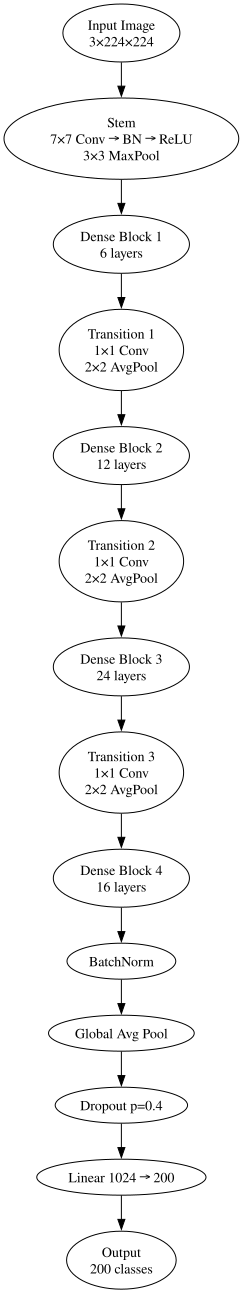

In [15]:
from graphviz import Digraph

dot = Digraph(format="png")
dot.attr(rankdir="TB")

dot.node("I", "Input Image\n3×224×224")
dot.node("S", "Stem\n7×7 Conv → BN → ReLU\n3×3 MaxPool")

dot.node("DB1", "Dense Block 1\n6 layers")
dot.node("T1", "Transition 1\n1×1 Conv\n2×2 AvgPool")

dot.node("DB2", "Dense Block 2\n12 layers")
dot.node("T2", "Transition 2\n1×1 Conv\n2×2 AvgPool")

dot.node("DB3", "Dense Block 3\n24 layers")
dot.node("T3", "Transition 3\n1×1 Conv\n2×2 AvgPool")

dot.node("DB4", "Dense Block 4\n16 layers")
dot.node("BN", "BatchNorm")
dot.node("GAP", "Global Avg Pool")

dot.node("DO", "Dropout p=0.4")
dot.node("FC", "Linear 1024 → 200")
dot.node("O", "Output\n200 classes")

edges = [
    ("I","S"), ("S","DB1"), ("DB1","T1"), ("T1","DB2"),
    ("DB2","T2"), ("T2","DB3"), ("DB3","T3"),
    ("T3","DB4"), ("DB4","BN"), ("BN","GAP"),
    ("GAP","DO"), ("DO","FC"), ("FC","O")
]

for e in edges:
    dot.edge(*e)

dot

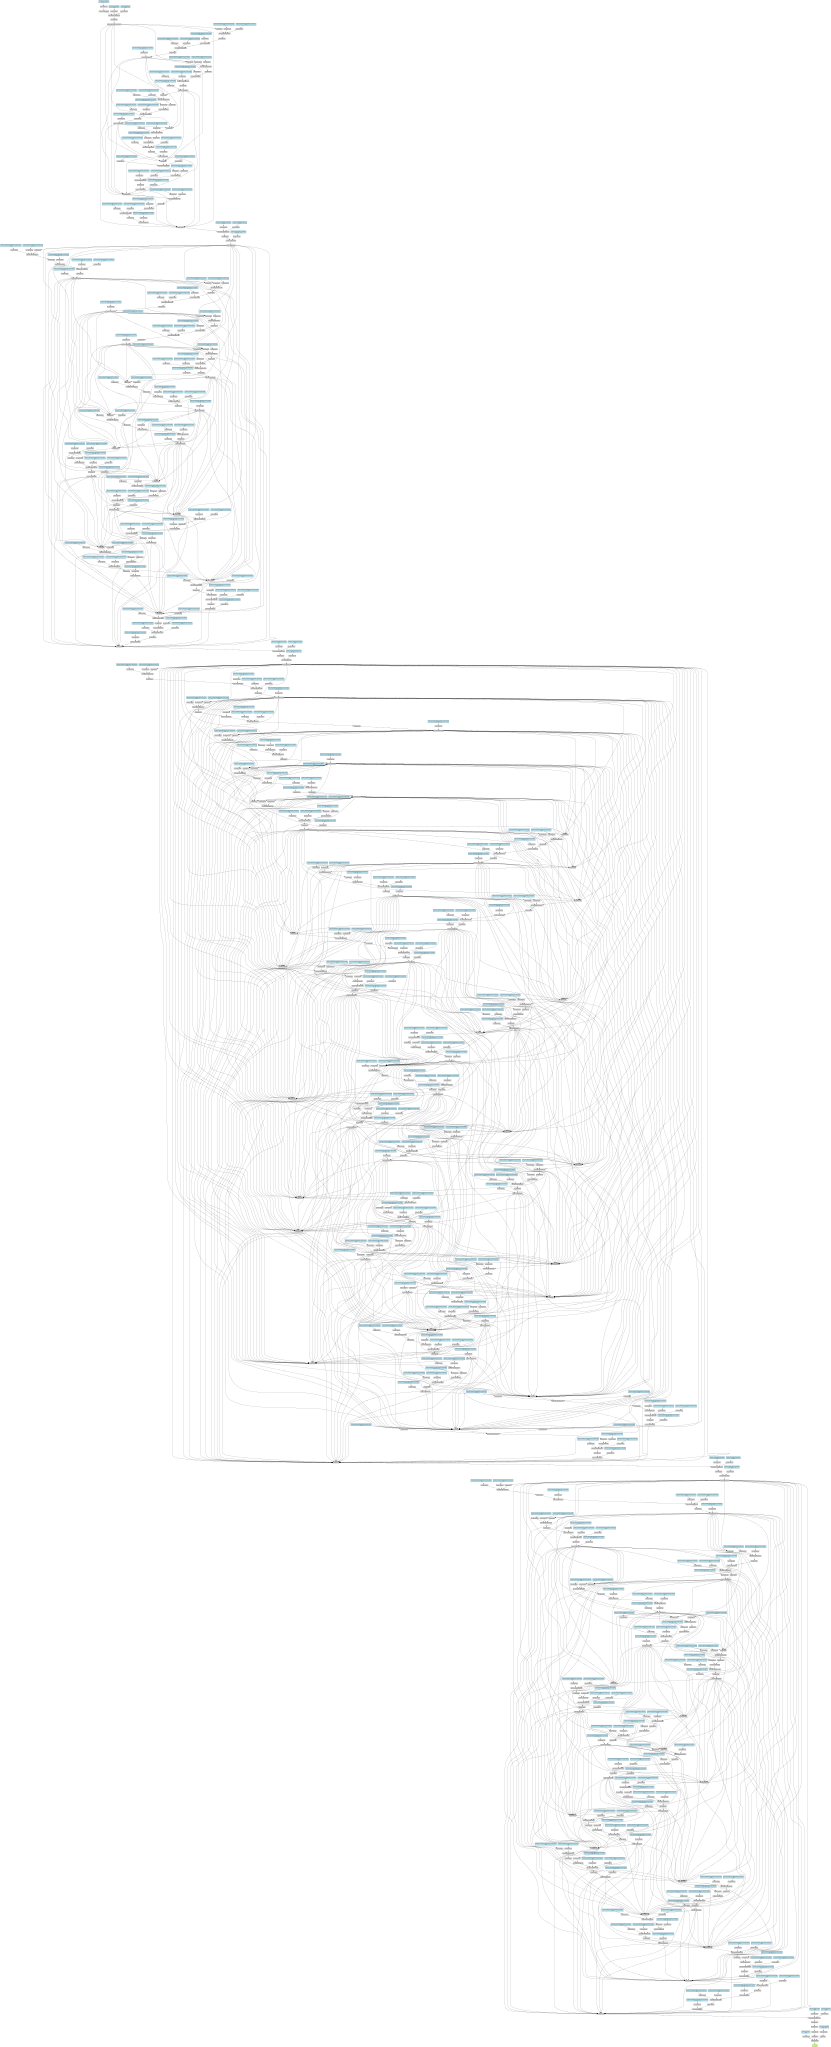

In [14]:
from torchviz import make_dot
x = torch.randn(1,3,224,224)
y = model(x)
make_dot(y, params=dict(model.named_parameters()))